# Quantum Annealing - Noisy Simulation (Bonus TODO 7)

We simulate D-Wave evolution with noise on the Hamiltonian to see how it affects the spectral gap.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from Problem.IsingProblem import IsingProblem
from quantum_solver.dwave_simulator import (DwaveSimulator, plot_eigenvalues,
    plot_spectral_gap, create_ising_instance_random)

## Noiseless vs noisy comparison

In [2]:
# Create instance
ising = create_ising_instance_random(6, weight_range=1.0, seed=42)
sim = DwaveSimulator(n_steps=101)

# Noiseless
eigs_clean, _ = sim.simulate_evolution(ising, nb_eigenvalues=5)

# Noisy with different noise levels
np.random.seed(123)
eigs_low = sim.simulate_evolution_noisy(ising, noise_std=0.01, nb_eigenvalues=5)
np.random.seed(123)
eigs_med = sim.simulate_evolution_noisy(ising, noise_std=0.1, nb_eigenvalues=5)
np.random.seed(123)
eigs_high = sim.simulate_evolution_noisy(ising, noise_std=0.5, nb_eigenvalues=5)

print("Simulations done.")

Simulations done.


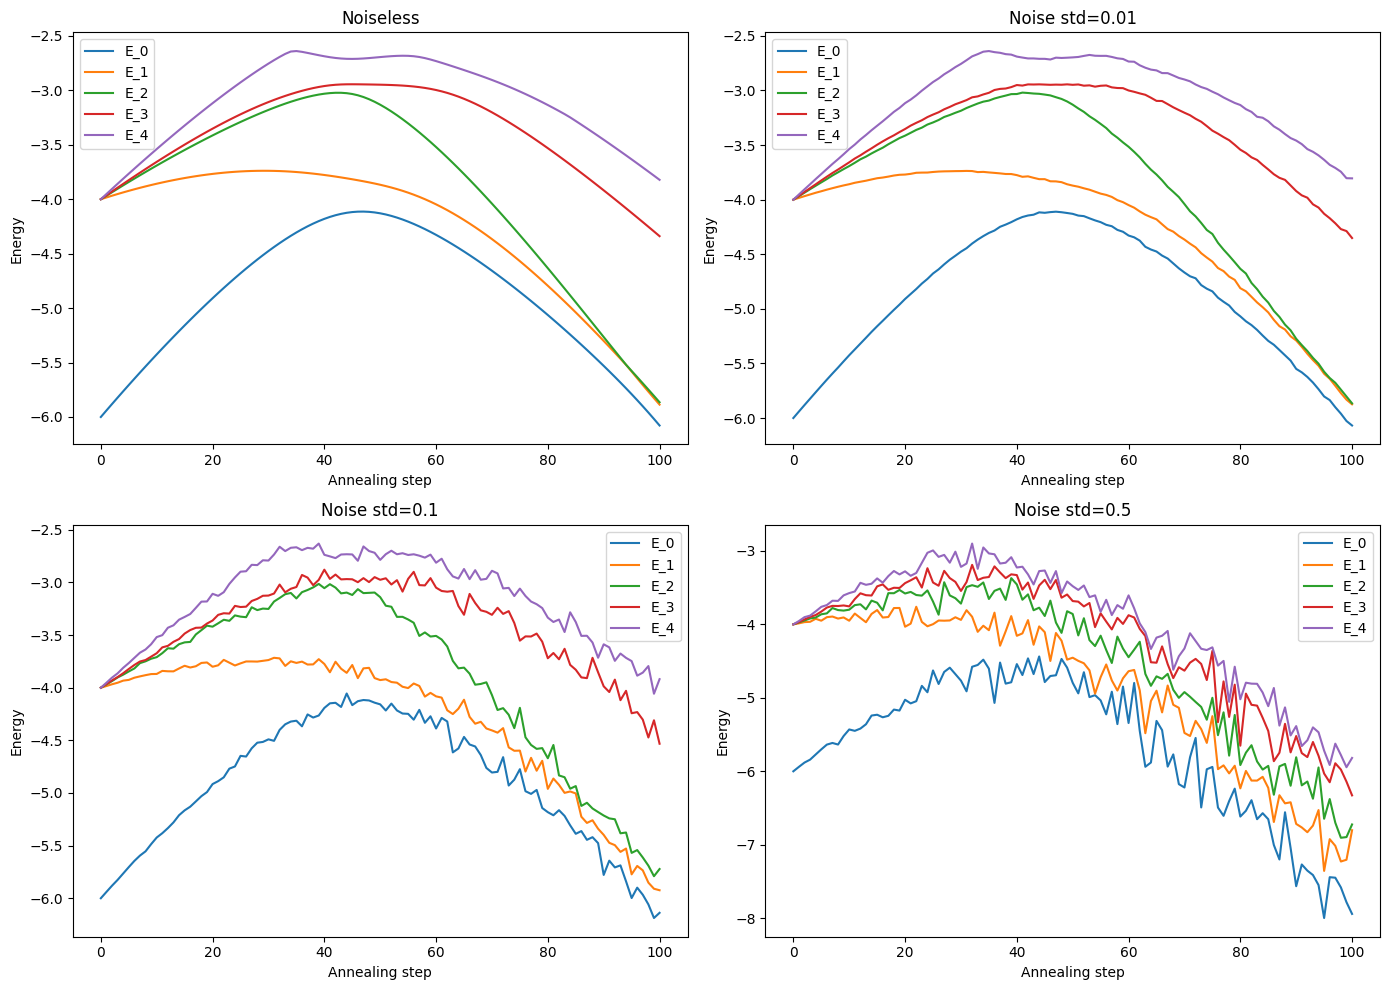

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Noiseless
plt.sca(axes[0, 0])
plot_eigenvalues(eigs_clean, title="Noiseless")

# Low noise
plt.sca(axes[0, 1])
plot_eigenvalues(eigs_low, title="Noise std=0.01")

# Medium noise
plt.sca(axes[1, 0])
plot_eigenvalues(eigs_med, title="Noise std=0.1")

# High noise
plt.sca(axes[1, 1])
plot_eigenvalues(eigs_high, title="Noise std=0.5")

plt.tight_layout()
plt.show()

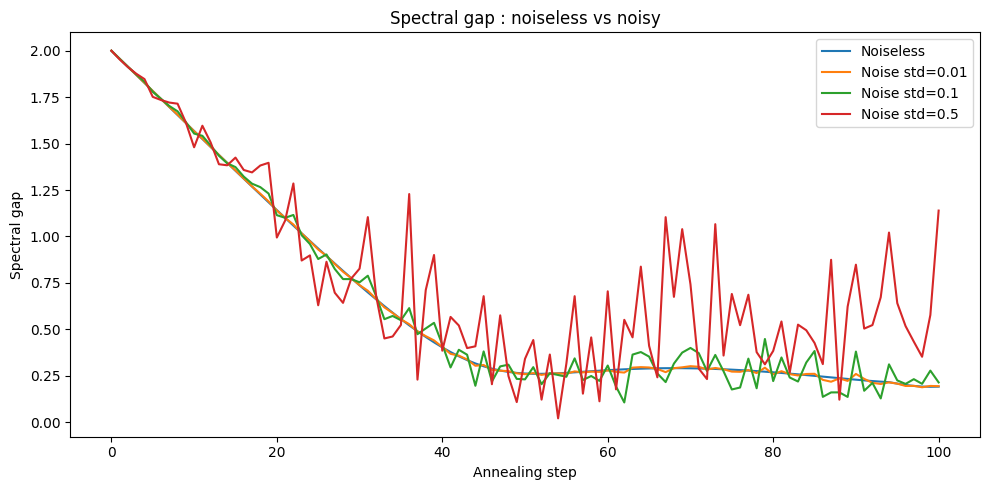

Min gap noiseless : 0.190763
Min gap noise=0.01 : 0.188279
Min gap noise=0.1 : 0.106510
Min gap noise=0.5 : 0.020987


In [4]:
# Compare spectral gaps
gaps_clean = [eigs_clean[s][1] - eigs_clean[s][0] for s in range(101)]
gaps_low = [eigs_low[s][1] - eigs_low[s][0] for s in range(101)]
gaps_med = [eigs_med[s][1] - eigs_med[s][0] for s in range(101)]
gaps_high = [eigs_high[s][1] - eigs_high[s][0] for s in range(101)]

plt.figure(figsize=(10, 5))
plt.plot(gaps_clean, label='Noiseless')
plt.plot(gaps_low, label='Noise std=0.01')
plt.plot(gaps_med, label='Noise std=0.1')
plt.plot(gaps_high, label='Noise std=0.5')
plt.xlabel('Annealing step')
plt.ylabel('Spectral gap')
plt.title('Spectral gap : noiseless vs noisy')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Min gap noiseless : {min(gaps_clean):.6f}")
print(f"Min gap noise=0.01 : {min(gaps_low):.6f}")
print(f"Min gap noise=0.1 : {min(gaps_med):.6f}")
print(f"Min gap noise=0.5 : {min(gaps_high):.6f}")

At the beginning of the evolution, the noise is **not very visible** because A(s) is large and B(s) is small. Since the noise is only on H_final (which is multiplied by B(s)), it is almost invisible when B(s) is close to 0. As the annealing progresses and B(s) grows, the noise becomes more and more visible.

In general, noise **reduces** the spectral gap because it introduces random perturbations that can cause level crossings or anticrossings, making the energy levels get closer together.

## Noise on H_init too

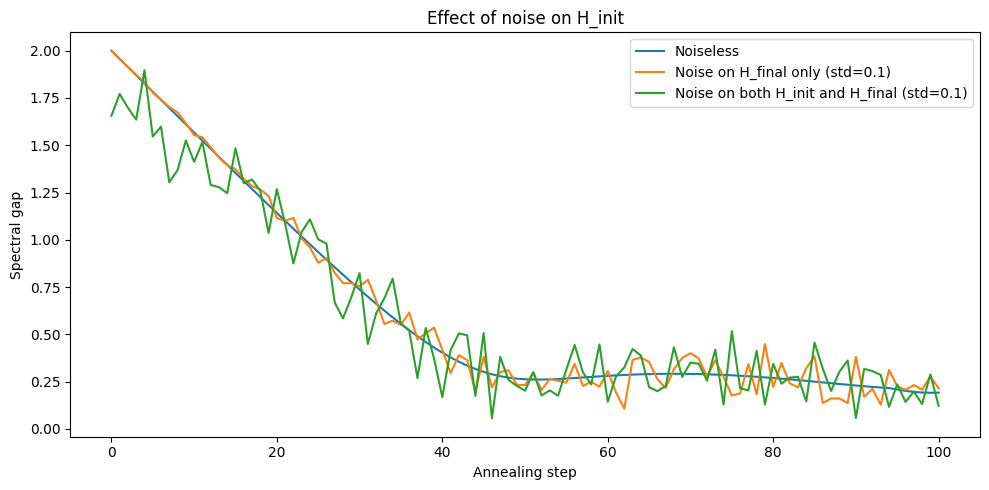

Min gap noise H_final only : 0.106510
Min gap noise on both : 0.055441


In [5]:
np.random.seed(456)
eigs_both_noise = sim.simulate_evolution_noisy(ising, noise_std=0.1, nb_eigenvalues=5, noise_on_init=True)

gaps_both = [eigs_both_noise[s][1] - eigs_both_noise[s][0] for s in range(101)]

plt.figure(figsize=(10, 5))
plt.plot(gaps_clean, label='Noiseless')
plt.plot(gaps_med, label='Noise on H_final only (std=0.1)')
plt.plot(gaps_both, label='Noise on both H_init and H_final (std=0.1)')
plt.xlabel('Annealing step')
plt.ylabel('Spectral gap')
plt.title('Effect of noise on H_init')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Min gap noise H_final only : {min(gaps_med):.6f}")
print(f"Min gap noise on both : {min(gaps_both):.6f}")

Adding noise on H_init too makes the situation **worse** because now both Hamiltonians are noisy. The spectral gap is even more perturbed, especially at the beginning of the evolution where H_init dominates. The noise on H_init disrupts the initial superposition state, meaning the system doesn't start in the ideal ground state of H_init.

## Is this noise model realistic?

This noise model is a simplification. In real quantum computers:
- The noise is not purely Gaussian on the Hamiltonian coefficients. Real quantum noise includes decoherence (T1 and T2 processes), which causes the quantum state to lose coherence over time.
- In our model, the noise changes at each time step independently, but in reality, noise can be correlated in time (1/f noise is common in superconducting qubits).
- We model the noise as additive on the full Hamiltonian matrix, but in reality the noise acts on individual qubit parameters (h_i and J_ij) independently, not as a random matrix.
- Real quantum annealers also have thermal noise from the environment (the system is not at absolute zero).

To improve the model, we could:
1. Add noise independently on each h_i and J_ij parameter instead of on the full matrix
2. Include time-correlated noise (e.g., using a colored noise model)
3. Add a thermal bath model using the Lindblad master equation instead of just Hamiltonian noise

## Conclusion on noise profile

When the noise gets stronger, the spectral gap decreases. Since the annealing time depends on 1/gap^2 (from the adiabatic theorem), a smaller gap means the annealing needs to be **much slower** to maintain the system in the ground state. So stronger noise = need for slower annealing = worse performance.